# Q-Learning with ALE/MarioBros-v5
## 18 Discrete Actions, RAM-State Aggregation, Training, Convergence, Q-Table Analysis, and Trained-Agent Rendering

This notebook uses the **actual Atari Mario Bros environment from the Arcade Learning Environment (ALE) through Gymnasium**.

Mario Bros is useful for extending a Q-Learning portfolio because its action space contains **18 discrete actions**, much larger than the action spaces in FrozenLake, Taxi, CliffWalking, Blackjack, or MountainCar.

The challenge is the state space.

The default observation is a video frame, while the RAM version returns a 128-byte state vector. A direct tabular Q-table over all possible raw observations is not practical.

Therefore, this notebook uses:

$$
\boxed{
\text{ALE RAM observation}
\rightarrow
\text{deterministic state aggregation}
\rightarrow
\text{tabular Q-Learning}
}
$$

The notebook includes:

- the actual Gymnasium/ALE Mario Bros environment;
- all 18 discrete actions;
- RGB rendering inside Colab;
- RAM observations for learning;
- deterministic hash-based state aggregation;
- Q-Learning from scratch;
- the first 60 Q-value updates;
- training reward and Q-update convergence plots;
- the final learned Q-table;
- most-visited state buckets and their greedy actions;
- action-use analysis;
- evaluation without exploration;
- a GIF of the trained agent playing the actual Mario Bros environment.

> **Important:** this is a tabular approximation of the Atari problem. It does not claim to recover the exact optimal Q-function of the original raw Atari state space. Atari-scale image/RAM problems are one reason Deep Q-Networks (DQN) are commonly used.

In [6]:
%pip install -q "gymnasium[atari]" imageio pillow

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import zlib
import imageio.v2 as imageio

from IPython.display import Image as IPyImage, display

gym.register_envs(ale_py)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)

## 1. Problem Description

Mario Bros is an Atari arcade game in which the player moves Mario around a platform-based screen and interacts with enemies.

For reinforcement learning, the game provides:

- a current observation;
- one of 18 discrete joystick/button actions;
- a numerical game reward;
- a new observation;
- episode termination/truncation information.

### Objective

The learning objective is to maximize cumulative game reward:

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\cdots.
$$

Unlike a small gridworld, there is no simple manually specified goal cell. The reward comes directly from the Atari game.

## 2. Actual ALE/Gymnasium Environment

For learning we use the RAM observation variant:

```python
ALE/MarioBros-ram-v5
```

The observation is

$$
S_t^{\text{RAM}}\in\{0,\ldots,255\}^{128}.
$$

For rendering, `render_mode="rgb_array"` still provides the actual game screen.

The action space is

$$
\mathcal A=\{0,1,\ldots,17\}.
$$

Environment: ALE/MarioBros-v5
Observation space: Box(0, 255, (210, 160, 3), uint8)
Action space: Discrete(18)
RAM observation shape: (210, 160, 3)
RAM dtype: uint8


,Action ID,Meaning
0,0,NOOP
1,1,FIRE
2,2,UP
3,3,RIGHT
4,4,LEFT
5,5,DOWN
6,6,UPRIGHT
7,7,UPLEFT
8,8,DOWNRIGHT
9,9,DOWNLEFT


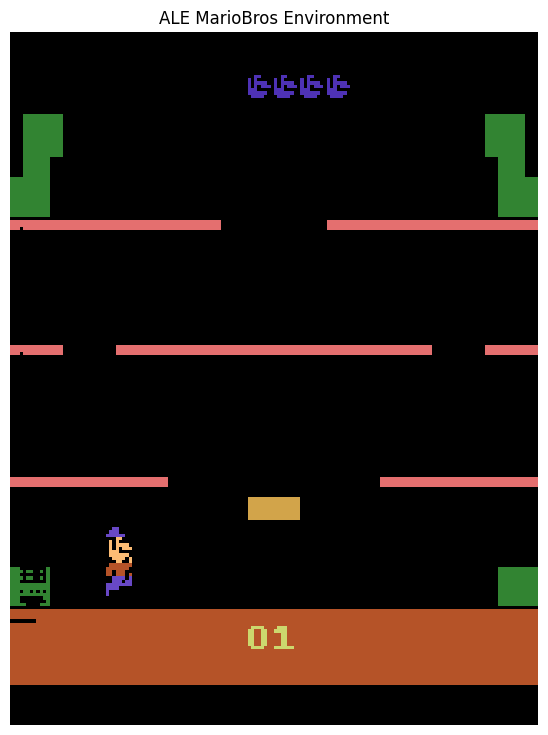

In [8]:
ENV_ID = "ALE/MarioBros-v5"

env = gym.make(
    ENV_ID,
    render_mode="rgb_array",
    repeat_action_probability=0.0
)

observation, info = env.reset(seed=7)

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("RAM observation shape:", observation.shape)
print("RAM dtype:", observation.dtype)

ACTION_NAMES = env.unwrapped.get_action_meanings()

action_table = pd.DataFrame({
    "Action ID": np.arange(env.action_space.n),
    "Meaning": ACTION_NAMES
})

display(action_table)

frame = env.render()

plt.figure(figsize=(7, 9))
plt.imshow(frame)
plt.axis("off")
plt.title("ALE MarioBros Environment")
plt.show()

## 3. The 18 Discrete Actions

The Mario Bros ALE environment exposes the full Atari action set:

$$
|\mathcal A|=18.
$$

The actions include:

- no operation;
- fire;
- directional movement;
- direction + fire combinations.

This gives the Q-table 18 action columns:

$$
Q(s,0),Q(s,1),\ldots,Q(s,17).
$$

This notebook is therefore useful for showing how Q-Learning behaves when the **action space is much larger** than in standard Toy Text examples.

## 4. Why Raw Atari States Cannot Be Used Directly as a Normal Q-Table

The RAM observation contains 128 bytes.

If every byte can take 256 possible values, the theoretical space is enormous:

$$
256^{128}.
$$

Most of these combinations may never occur, but the space is still far too large for a conventional dense Q-table.

The RGB version is even larger because each state is an image.

Therefore, some form of state representation or function approximation is required.

## 5. State Aggregation for Tabular Q-Learning

To keep this example tabular, each 128-byte RAM observation is mapped deterministically into one of a fixed number of state buckets.

We use

$$
N_{\text{buckets}}=4096.
$$

The mapping is

$$
\phi(S_t^{\text{RAM}})
\rightarrow
\{0,1,\ldots,4095\}.
$$

The resulting Q-table has

$$
4096\times18=73{,}728
$$

entries.

### Why call this an approximation?

Different RAM states can occasionally map to the same bucket. This is called a **hash collision**.

Therefore,

$$
Q(\phi(s),a)
$$

approximates the value of the underlying Atari states assigned to that bucket.

In [9]:
N_STATE_BUCKETS = 4096

def aggregate_state(ram_observation):
    ram_bytes = np.asarray(ram_observation, dtype=np.uint8).tobytes()
    return int(zlib.crc32(ram_bytes) % N_STATE_BUCKETS)

bucket = aggregate_state(observation)

print("Example RAM state mapped to bucket:", bucket)
print("Q-table shape:", (N_STATE_BUCKETS, env.action_space.n))

Example RAM state mapped to bucket: 2034
Q-table shape: (4096, np.int64(18))


## 6. Q-Learning Update

After state aggregation, the standard Q-Learning update is applied:

$$
Q(Z_t,A_t)
\leftarrow
Q(Z_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(Z_{t+1},a)
-
Q(Z_t,A_t)
\right],
$$

where

$$
Z_t=\phi(S_t^{\text{RAM}})
$$

is the aggregated discrete state.

The behavior policy is $\epsilon$-greedy:

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon\\
\arg\max_aQ(Z_t,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

## 7. Training Configuration

Atari episodes can be much longer and more expensive than Toy Text environments.

The default portfolio configuration below uses:

- 800 training episodes;
- at most 2,500 environment decisions per episode;
- learning rate

$$
\alpha=0.10;
$$

- discount factor

$$
\gamma=0.99;
$$

- decaying $\epsilon$-greedy exploration.

You can increase `N_EPISODES` later if you want a longer training run.

In [10]:
N_EPISODES = 800
MAX_STEPS = 2500

ALPHA = 0.10
GAMMA = 0.99

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

SEED = 7

## 8. Train the Q-Learning Agent

During training we record:

- episode return;
- episode length;
- exploration rate;
- number of unique state buckets visited;
- maximum absolute Q-value update in each episode;
- first 60 individual Q-Learning updates.

In [11]:
def train_q_learning():
    rng = np.random.default_rng(SEED)

    Q = np.zeros(
        (N_STATE_BUCKETS, env.action_space.n),
        dtype=np.float32
    )

    visit_counts = np.zeros(N_STATE_BUCKETS, dtype=np.int64)

    history = []
    update_log = []

    epsilon = EPSILON_START
    update_number = 0

    for episode in range(1, N_EPISODES + 1):
        observation, _ = env.reset(seed=SEED + episode)
        state = aggregate_state(observation)

        total_reward = 0.0
        max_abs_update = 0.0

        for step in range(1, MAX_STEPS + 1):
            visit_counts[state] += 1

            if rng.random() < epsilon:
                action = int(rng.integers(env.action_space.n))
                selection = "explore"
            else:
                q_values = Q[state]
                best_actions = np.flatnonzero(
                    np.isclose(q_values, q_values.max())
                )
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_observation, reward, terminated, truncated, _ = env.step(action)
            next_state = aggregate_state(next_observation)

            old_q = float(Q[state, action])

            if terminated or truncated:
                max_next_q = 0.0
                target = float(reward)
            else:
                max_next_q = float(np.max(Q[next_state]))
                target = float(reward) + GAMMA * max_next_q

            td_error = target - old_q
            update_amount = ALPHA * td_error

            Q[state, action] += update_amount

            max_abs_update = max(
                max_abs_update,
                abs(update_amount)
            )

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "State Bucket": state,
                    "Action ID": action,
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next State Bucket": next_state,
                    "Old Q": old_q,
                    "Max Next Q": max_next_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": float(Q[state, action]),
                    "Epsilon": epsilon
                })

            total_reward += float(reward)
            state = next_state

            if terminated or truncated:
                break

        history.append({
            "Episode": episode,
            "Return": total_reward,
            "Episode Length": step,
            "Epsilon": epsilon,
            "Unique Buckets Visited": int(np.count_nonzero(visit_counts)),
            "Max Absolute Q Update": max_abs_update
        })

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY
        )

        if episode % 50 == 0:
            print(
                f"Episode {episode:4d} | "
                f"Return {total_reward:8.2f} | "
                f"Steps {step:4d} | "
                f"Epsilon {epsilon:.3f} | "
                f"Buckets {np.count_nonzero(visit_counts)}"
            )

    return (
        Q,
        visit_counts,
        pd.DataFrame(history),
        pd.DataFrame(update_log)
    )

Q, visit_counts, history, update_log = train_q_learning()

Episode   50 | Return     0.00 | Steps  904 | Epsilon 0.778 | Buckets 4096
Episode  100 | Return     0.00 | Steps  708 | Epsilon 0.606 | Buckets 4096
Episode  150 | Return     0.00 | Steps  837 | Epsilon 0.471 | Buckets 4096
Episode  200 | Return     0.00 | Steps 1702 | Epsilon 0.367 | Buckets 4096
Episode  250 | Return     0.00 | Steps  429 | Epsilon 0.286 | Buckets 4096
Episode  300 | Return     0.00 | Steps  618 | Epsilon 0.222 | Buckets 4096
Episode  350 | Return     0.00 | Steps  791 | Epsilon 0.173 | Buckets 4096
Episode  400 | Return     0.00 | Steps  396 | Epsilon 0.135 | Buckets 4096
Episode  450 | Return     0.00 | Steps 1353 | Epsilon 0.105 | Buckets 4096
Episode  500 | Return  1600.00 | Steps  615 | Epsilon 0.082 | Buckets 4096
Episode  550 | Return     0.00 | Steps 1759 | Epsilon 0.063 | Buckets 4096
Episode  600 | Return     0.00 | Steps 1185 | Epsilon 0.050 | Buckets 4096
Episode  650 | Return   800.00 | Steps  823 | Epsilon 0.050 | Buckets 4096
Episode  700 | Return    

## 9. First 60 Q-Value Updates

The table below shows the first 60 state-action updates.

Because there are 18 actions, this is also a useful way to inspect which actions are sampled during early exploration.

In [12]:
display(update_log.round(5))

,Update,Episode,Step,State Bucket,Action ID,Action,Reward,Next State Bucket,Old Q,Max Next Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,2034,12,LEFTFIRE,0.0,774,0.0,0.0,0.0,0.0,0.0,1.0
1,2,1,2,774,16,DOWNRIGHTFIRE,0.0,3865,0.0,0.0,0.0,0.0,0.0,1.0
2,3,1,3,3865,0,NOOP,0.0,774,0.0,0.0,0.0,0.0,0.0,1.0
3,4,1,4,774,5,DOWN,0.0,2945,0.0,0.0,0.0,0.0,0.0,1.0
4,5,1,5,2945,8,DOWNRIGHT,0.0,467,0.0,0.0,0.0,0.0,0.0,1.0
5,6,1,6,467,14,UPRIGHTFIRE,0.0,3107,0.0,0.0,0.0,0.0,0.0,1.0
6,7,1,7,3107,14,UPRIGHTFIRE,0.0,296,0.0,0.0,0.0,0.0,0.0,1.0
7,8,1,8,296,5,DOWN,0.0,1387,0.0,0.0,0.0,0.0,0.0,1.0
8,9,1,9,1387,17,DOWNLEFTFIRE,0.0,764,0.0,0.0,0.0,0.0,0.0,1.0
9,10,1,10,764,8,DOWNRIGHT,0.0,81,0.0,0.0,0.0,0.0,0.0,1.0


## 10. Training Reward

For Atari, there is no small exact $Q^*$ table available for comparison.

Therefore, one practical learning curve is the moving average episode return.

Higher return indicates that the policy is obtaining more reward from the game.

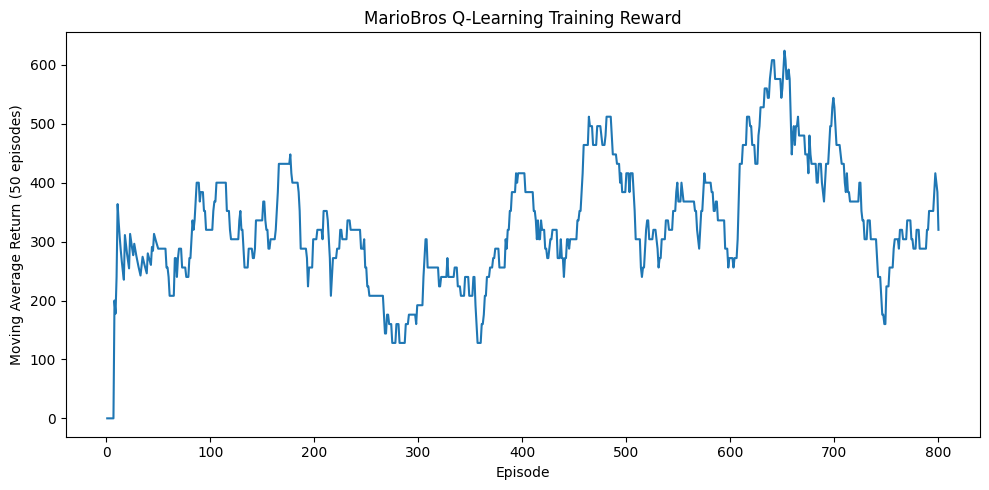

In [13]:
REWARD_WINDOW = 50

history["Moving Average Return"] = (
    history["Return"]
    .rolling(REWARD_WINDOW, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Moving Average Return"]
)
plt.xlabel("Episode")
plt.ylabel(f"Moving Average Return ({REWARD_WINDOW} episodes)")
plt.title("MarioBros Q-Learning Training Reward")
plt.tight_layout()
plt.show()

## 11. Q-Value Update Magnitude

A second learning diagnostic is the largest Q-value change in each episode.

As estimates stabilize, the average magnitude of Q-updates should generally become smaller, although Atari rewards and changing visited states can make this curve noisy.

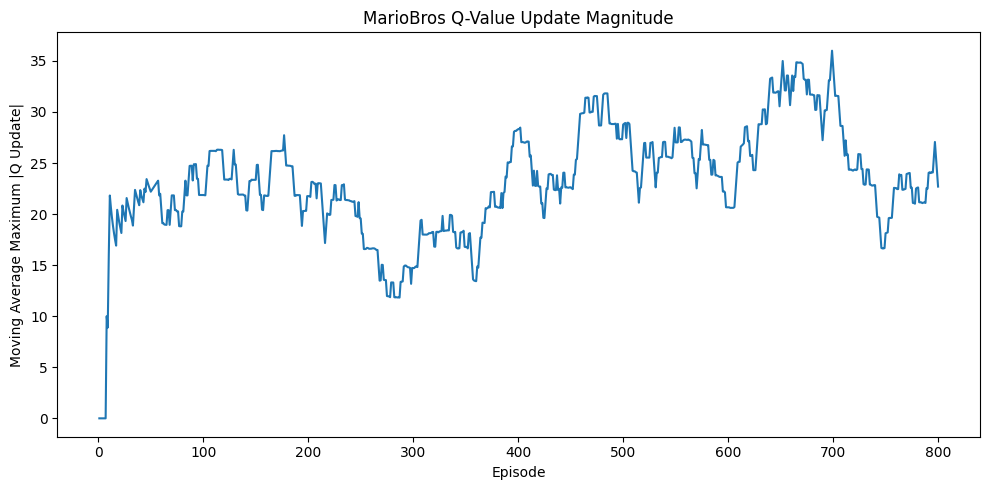

In [14]:
history["Moving Average Max Q Update"] = (
    history["Max Absolute Q Update"]
    .rolling(REWARD_WINDOW, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Moving Average Max Q Update"]
)
plt.xlabel("Episode")
plt.ylabel("Moving Average Maximum |Q Update|")
plt.title("MarioBros Q-Value Update Magnitude")
plt.tight_layout()
plt.show()

## 12. Growth of the Visited State Table

The hashed Q-table has 4,096 possible state buckets.

The following graph shows how many distinct buckets the agent actually encounters during training.

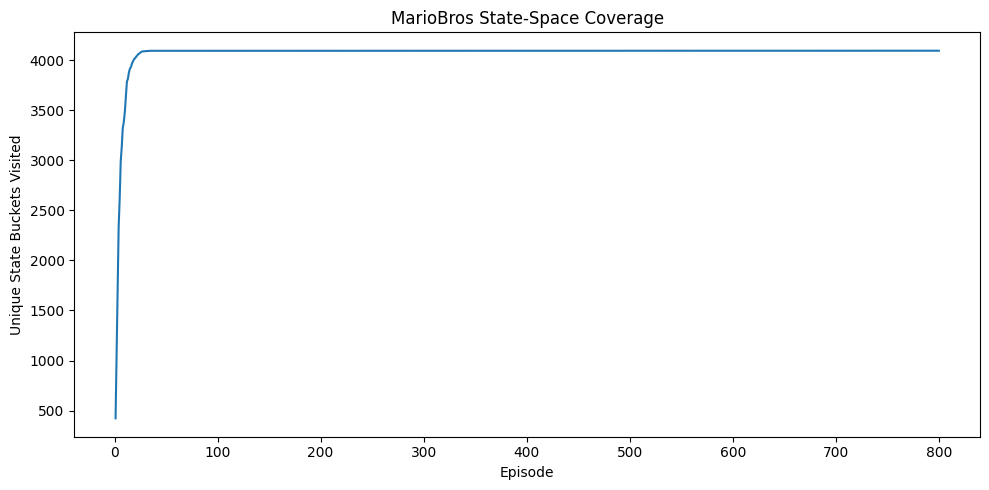

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(
    history["Episode"],
    history["Unique Buckets Visited"]
)
plt.xlabel("Episode")
plt.ylabel("Unique State Buckets Visited")
plt.title("MarioBros State-Space Coverage")
plt.tight_layout()
plt.show()

## 13. Final Learned Q-Table

The complete tabular approximation has shape

$$
4096\times18.
$$

Displaying every row is possible but not very informative because many buckets may never be visited.

We therefore show:

1. the most frequently visited state buckets;
2. all 18 learned action values for each;
3. the greedy action in each bucket.

In [16]:
TOP_N_BUCKETS = 50

most_visited = np.argsort(visit_counts)[::-1][:TOP_N_BUCKETS]

rows = []

for state_bucket in most_visited:
    row = {
        "State Bucket": int(state_bucket),
        "Visits": int(visit_counts[state_bucket])
    }

    for action_id, action_name in enumerate(ACTION_NAMES):
        row[f"Q[{action_id}] {action_name}"] = float(
            Q[state_bucket, action_id]
        )

    best_action = int(np.argmax(Q[state_bucket]))

    row["Greedy Action ID"] = best_action
    row["Greedy Action"] = ACTION_NAMES[best_action]

    rows.append(row)

top_q_table = pd.DataFrame(rows)

display(top_q_table.round(4))

,State Bucket,Visits,Q[0] NOOP,Q[1] FIRE,Q[2] UP,Q[3] RIGHT,Q[4] LEFT,Q[5] DOWN,Q[6] UPRIGHT,Q[7] UPLEFT,Q[8] DOWNRIGHT,Q[9] DOWNLEFT,Q[10] UPFIRE,Q[11] RIGHTFIRE,Q[12] LEFTFIRE,Q[13] DOWNFIRE,Q[14] UPRIGHTFIRE,Q[15] UPLEFTFIRE,Q[16] DOWNRIGHTFIRE,Q[17] DOWNLEFTFIRE,Greedy Action ID,Greedy Action
0,774,1772,2.8531,3.0080,6.4690,2.4550,2.0395,4.0554,2.4418,4.4757,3.0180,2.8232,2.4505,4.0991,3.4318,2.1089,2.1875,2.4411,2.0760,3.5367,2,UP
1,2034,1010,2.6739,2.6538,1.1919,0.8627,1.6279,6.4874,1.4235,2.8517,3.0465,0.3450,2.4442,1.3124,1.7279,1.6611,1.5042,2.3755,1.8410,1.5730,5,DOWN
2,3865,949,1.9071,2.3748,2.3005,0.8378,2.9803,2.3467,1.9790,6.5322,1.6109,0.1542,1.7838,2.5617,2.5911,1.2120,1.3223,1.8074,2.0169,1.3245,7,UPLEFT
3,2945,949,2.9797,1.3457,6.5320,1.3933,0.4633,2.2901,2.2455,1.0652,1.1030,1.7753,1.4263,2.4610,1.7245,0.5784,2.0560,1.8193,1.9249,1.2171,2,UP
4,57,764,2.0365,0.9679,6.6147,1.6147,1.5726,2.4803,1.2700,2.3834,1.4832,1.2083,0.4518,3.6631,1.3092,0.4270,1.8568,1.1699,2.0171,0.7360,2,UP
5,1161,714,0.4339,1.0497,0.7540,0.7796,2.5303,1.4510,0.9345,1.3681,2.4591,1.6583,2.5983,2.9239,2.0238,2.2927,6.8563,1.2480,2.6461,1.6441,14,UPRIGHTFIRE
6,2271,652,7.3061,1.2516,0.9711,2.2149,1.4771,0.4789,1.6590,1.2762,0.4904,1.5366,0.6496,0.5209,0.6127,1.0720,1.1094,2.1341,1.5101,0.0000,0,NOOP
7,3812,651,6.5855,1.6340,1.9071,1.3191,0.4386,1.9063,1.7321,1.2483,1.1698,0.9211,0.3202,0.4539,0.3424,1.0165,0.1205,2.7678,0.7425,1.9584,0,NOOP
8,2568,622,0.6952,1.9998,1.5244,0.9311,1.3224,1.5168,0.9542,0.7961,1.6630,1.5424,0.7611,1.5011,1.4967,6.4221,1.4853,1.1086,1.1029,1.2574,13,DOWNFIRE
9,588,622,1.0166,1.4497,1.0316,1.1298,0.5860,0.8486,0.6394,1.3279,0.6521,1.3352,0.7652,1.7924,0.9698,2.1854,0.7565,6.3471,0.2954,0.2819,15,UPLEFTFIRE


## 14. Full Learned Q-Table

The complete $4096\times18$ table is available below.

The index is the aggregated state bucket and the columns are the Atari actions.

In [17]:
full_q_table = pd.DataFrame(
    Q,
    columns=[
        f"{i}: {name}"
        for i, name in enumerate(ACTION_NAMES)
    ]
)

full_q_table.index.name = "State Bucket"

display(full_q_table.round(4))

,0: NOOP,1: FIRE,2: UP,3: RIGHT,4: LEFT,5: DOWN,6: UPRIGHT,7: UPLEFT,8: DOWNRIGHT,9: DOWNLEFT,10: UPFIRE,11: RIGHTFIRE,12: LEFTFIRE,13: DOWNFIRE,14: UPRIGHTFIRE,15: UPLEFTFIRE,16: DOWNRIGHTFIRE,17: DOWNLEFTFIRE
State Bucket,,,,,,,,,,,,,,,,,,
0,0.0000,0.0000,0.4990,0.0000,6.4295,0.4533,0.0007,0.5070,0.3757,0.7976,0.0000,0.2771,0.1141,0.6147,0.0000,0.0654,0.5082,0.1607
1,0.0477,0.7256,0.3291,0.4619,0.2185,0.2722,0.4349,0.1010,0.1544,1.9935,0.0000,0.1526,0.0102,0.8686,0.0630,0.8529,0.9435,8.0226
2,2.9694,0.1942,0.2814,0.0000,0.6704,0.5343,0.2988,0.0000,0.9821,0.0007,6.3898,0.0000,0.0000,0.7769,0.1141,0.6333,0.0000,0.1568
3,0.6254,0.4326,0.0533,1.0260,1.2486,0.3857,0.0520,0.2316,0.7767,0.0000,0.0259,0.4589,0.0513,0.6118,0.1009,0.5813,6.4454,0.5525
4,7.4875,0.5065,0.4605,0.6571,0.5723,0.7169,0.0322,0.3532,0.4026,0.1794,0.4165,0.3635,0.0000,0.1870,0.8241,0.5747,0.7087,0.6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,1.1720,0.2186,0.2421,0.0244,0.9885,1.1621,0.2327,0.3970,6.5836,0.0984,0.7382,0.0589,2.7842,0.0008,0.1966,0.6479,0.0000,0.0312
4092,0.6467,0.0069,0.1273,0.0010,0.8232,0.5927,0.8527,0.7228,0.6107,6.4655,0.0051,0.4148,0.3769,0.8293,0.0000,0.6795,0.0831,0.2214
4093,0.2254,0.0646,0.5942,0.6966,0.0994,0.0000,0.0062,0.8697,0.9130,0.7606,0.1431,0.0001,0.0000,6.3574,1.0786,1.2407,0.0006,0.6003


## 15. Which Actions Does the Learned Policy Prefer?

For every visited state bucket, we find

$$
\pi(z)=\arg\max_aQ(z,a).
$$

The next table counts how often each of the 18 actions is the greedy choice among visited buckets.

In [18]:
visited_buckets = np.flatnonzero(visit_counts > 0)

greedy_actions = np.argmax(
    Q[visited_buckets],
    axis=1
)

action_preference = pd.DataFrame({
    "Action ID": np.arange(env.action_space.n),
    "Action": ACTION_NAMES,
    "Greedy State Buckets": [
        int(np.sum(greedy_actions == a))
        for a in range(env.action_space.n)
    ]
})

display(action_preference)

,Action ID,Action,Greedy State Buckets
0,0,NOOP,239
1,1,FIRE,194
2,2,UP,229
3,3,RIGHT,239
4,4,LEFT,260
5,5,DOWN,219
6,6,UPRIGHT,239
7,7,UPLEFT,226
8,8,DOWNRIGHT,219
9,9,DOWNLEFT,219


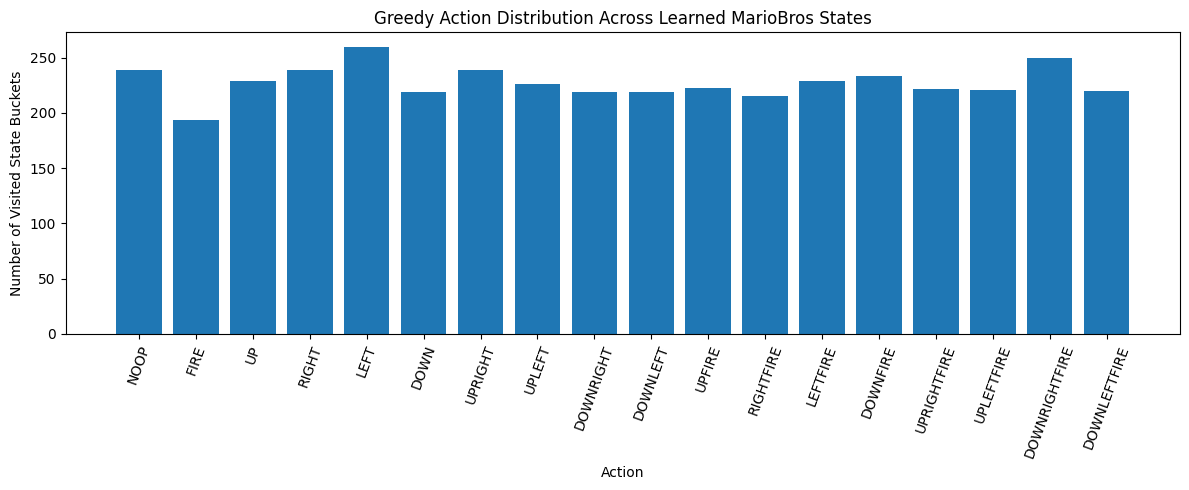

In [19]:
plt.figure(figsize=(12, 5))
plt.bar(
    action_preference["Action"],
    action_preference["Greedy State Buckets"]
)
plt.xticks(rotation=70)
plt.xlabel("Action")
plt.ylabel("Number of Visited State Buckets")
plt.title("Greedy Action Distribution Across Learned MarioBros States")
plt.tight_layout()
plt.show()

## 16. Evaluate the Trained Agent

The learned policy is evaluated without $\epsilon$-greedy exploration.

Because Atari is stochastic and the state representation is approximate, performance should be interpreted as an empirical result rather than an exact optimality guarantee.

In [20]:
def evaluate_agent(Q, n_episodes=20, seed=50000):
    returns = []
    lengths = []

    for episode in range(n_episodes):
        observation, _ = env.reset(seed=seed + episode)
        state = aggregate_state(observation)
        total_reward = 0.0

        for step in range(1, MAX_STEPS + 1):
            action = int(np.argmax(Q[state]))

            observation, reward, terminated, truncated, _ = env.step(action)
            state = aggregate_state(observation)

            total_reward += float(reward)

            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step)

    results = pd.DataFrame([{
        "Evaluation Episodes": n_episodes,
        "Mean Return": np.mean(returns),
        "Median Return": np.median(returns),
        "Best Return": np.max(returns),
        "Worst Return": np.min(returns),
        "Mean Episode Length": np.mean(lengths)
    }])

    return results

evaluation = evaluate_agent(Q)

display(evaluation.round(3))

,Evaluation Episodes,Mean Return,Median Return,Best Return,Worst Return,Mean Episode Length
0,20,0.0,0.0,0.0,0.0,975.0


## 17. Run the Trained Agent in the Actual Mario Bros Environment

The following cell runs the greedy policy and collects actual RGB frames from ALE.

To keep the GIF small enough for a notebook, only every fourth rendered frame is stored.

Steps: 975
Total reward: 0.0
Most common actions:
  16 DOWNRIGHTFIRE      -> 79
  15 UPLEFTFIRE         -> 76
  12 LEFTFIRE           -> 69
  11 RIGHTFIRE          -> 63
  13 DOWNFIRE           -> 59
   9 DOWNLEFT           -> 58
   6 UPRIGHT            -> 57
  14 UPRIGHTFIRE        -> 54
   2 UP                 -> 51
   0 NOOP               -> 50


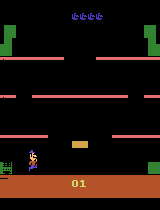

In [21]:
def save_gif(frames, filename, duration=0.05):
    imageio.mimsave(
        filename,
        frames,
        duration=duration,
        loop=0
    )
    display(IPyImage(filename=filename))

def record_trained_agent(
    Q,
    filename="mariobros_q_learning_agent.gif",
    seed=2026,
    max_steps=1500,
    capture_every=4
):
    frames = []

    observation, _ = env.reset(seed=seed)
    state = aggregate_state(observation)

    frames.append(env.render())

    total_reward = 0.0
    actions_taken = []

    for step in range(1, max_steps + 1):
        action = int(np.argmax(Q[state]))
        actions_taken.append(action)

        observation, reward, terminated, truncated, _ = env.step(action)
        state = aggregate_state(observation)

        total_reward += float(reward)

        if step % capture_every == 0:
            frames.append(env.render())

        if terminated or truncated:
            frames.append(env.render())
            break

    print("Steps:", step)
    print("Total reward:", total_reward)
    print("Most common actions:")

    action_counts = pd.Series(actions_taken).value_counts().sort_values(ascending=False)

    for action_id, count in action_counts.head(10).items():
        print(
            f"  {action_id:2d} {ACTION_NAMES[action_id]:18s} -> {count}"
        )

    save_gif(
        frames,
        filename,
        duration=0.05
    )

record_trained_agent(Q)

## 18. Why There Is No Exact Optimal Q-Table Here

For FrozenLake, Taxi, CliffWalking, and Blackjack, it is possible to obtain or calculate a compact reference $Q^*$.

Mario Bros is different.

The original state is a high-dimensional Atari observation, and the environment is stochastic. The table in this notebook is built over an **aggregated state representation**, not over every possible original Atari state.

Therefore, the final table is correctly described as:

$$
\boxed{\text{learned Q-table for the aggregated RAM state representation}}
$$

rather than the exact optimal Q-table for Mario Bros.

## 19. What This Example Adds to the Portfolio

This example extends the earlier Q-Learning notebooks in two important ways.

### Many discrete actions

$$
|\mathcal A|=18.
$$

The agent has far more choices at each decision than in the small Gymnasium environments.

### High-dimensional state representation

The Atari state cannot be stored directly in a practical dense table.

We therefore used

$$
\text{RAM observation}
\rightarrow
\text{state aggregation}
\rightarrow
Q(z,a).
$$

This also shows where tabular Q-Learning begins to reach its practical limits.

## 20. Connection to Deep Q-Learning

The main limitation of this notebook is the manually designed state aggregation.

Deep Q-Learning replaces the table with a neural network:

$$
Q(s,a;\theta).
$$

For raw Atari images, a Deep Q-Network can learn features directly from the observation instead of mapping RAM states into arbitrary hash buckets.

This makes Mario Bros a natural bridge from the **tabular Q-Learning portfolio** to a future **DQN portfolio**.